In [17]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import sys
from pathlib import Path
from scipy.optimize import least_squares
from scipy.signal import butter, sosfiltfilt

if __package__ in {None, ""}:
    sys.path.insert(0, str(Path("../").resolve()))
    
from tools.front.analyze_accel_mismatch import derive_gt
from backend.mag_to_travel_model_core import MagToTravelChunk, MagToTravelModelCore

np.set_printoptions(precision=3, suppress=True)

def print_err_stats(x, gt, center=False, prefix=""):
    if center:
        x = x.copy() - np.mean(x)
        gt = gt.copy() - np.mean(gt)
    error = x - gt
    rmse = np.mean(error ** 2) ** 0.5
    mae = np.mean(abs(error))
    me = np.mean(error)
    print(f"{prefix} RMSE: {rmse:.3f}, MAE: {mae:.3f}, ME: {me:.3f}")
    return rmse, mae, me

In [18]:
log_filename = "log103"

In [19]:
out_dir = f"../backend/run_artifacts/{log_filename}/cache/"
ws_file = out_dir + "/all.npz"
ws = np.load(ws_file)
print([str(key) for key in ws.keys()])

acc = ws["accel/lpfhp/proj__x"][:, 0]
a_s2_x = ws["accel/lpf/lis2__x"][:, 0]
travel = ws["travel__x"][:, 0]
mag = ws["mag/proj/corr/lpf__x"][:, 0]
mag_raw = ws["mag/lpf__x"]
mag_raw_mag = np.linalg.norm(mag_raw, axis=1)
mag_baseline = ws["mag_baseline"][0]
mag_proj_bad_mask = ws["mag/proj/bad_mask__x"][:, 0].astype(bool)
boring_mask = ws["boring_mask"].astype(bool)
mag_zv_points = ws["mag_zv_points"]
t, a_meas, a_gt, v = derive_gt(ws, use_gradient=True, use_raw=False)
dt_s = np.diff(t, prepend=t[0]-0.01)

print("Mag baseline:", mag_baseline)

['__log_config_hash', 'accel/lis1__t', 'accel/lis1__x', 'accel/lis2__t', 'accel/lis2__x', 'gyro/gyro1__t', 'gyro/gyro1__x', 'gyro/gyro2__t', 'gyro/gyro2__x', 'mag__t', 'mag__x', 'mag_lis__t', 'mag_lis__x', 'angle__t', 'angle__x', 'angle/bad_mask__t', 'angle/bad_mask__x', 'gyro/lpf/gyro1__t', 'gyro/lpf/gyro1__x', 'gyro/lpf/gyro2__t', 'gyro/lpf/gyro2__x', 'accel/lpf/lis1__t', 'accel/lpf/lis1__x', 'accel/lpf/lis2__t', 'accel/lpf/lis2__x', 'lis1_chunks_filt', 'lis2_chunks_filt', 'rotation_matrix', 'accel/lis2_in_lis1__t', 'accel/lis2_in_lis1__x', 'accel/relative__t', 'accel/relative__x', 'accel/lpf/relative__t', 'accel/lpf/relative__x', 'accel_trav_vec', 'mags_vs_means', 'accel/proj__t', 'accel/proj__x', 'accel/lpf/proj__t', 'accel/lpf/proj__x', 'accel/lpfhp/proj__t', 'accel/lpfhp/proj__x', 'angle/lpf__t', 'angle/lpf__x', 'travel__t', 'travel__x', 'boring_mask', 'mag/proj__t', 'mag/proj__x', 'mag/lpf__t', 'mag/lpf__x', 'mag_lis/lpf__t', 'mag_lis/lpf__x', 'mag/proj/lpf__t', 'mag/proj/lpf__x

In [20]:
# Try just using S2 to train

hp_fc_hz=1
sos_lp = butter(N=4, Wn=hp_fc_hz, btype="high", fs=100, output="sos")
#acc = -sosfiltfilt(sos_lp, a_s2_x)

In [21]:
model_builder = MagToTravelModelCore(train_with_mask=True, chunk_min_dx=10)

training_data = model_builder.create_training_data(
    mag, 
    acc,
    mag_proj_bad_mask,
    t,
    mag_baseline,
    mag_zv_points
)

chunks: list[MagToTravelChunk] = model_builder.chunks
#filts = model_builder.stats["chunks_filtered"]

print(len(chunks), " chunks for training")
#print(filts)

Training with mask, shape of bad mask (72985,) num bad samples 448
Candidate chunks: 1723
Eligible chunks: 1581
Using raw min mag 667.6498910271556 chunks 343
Training chunks: 343
Min mag at indices: 668.1491104012421 mean 3572.237949203982 max 28206.532189698566
(343, 3, 40)
343  chunks for training


In [22]:
slices = [chunk_i.slice_i for chunk_i in chunks]
mags = [chunk_i.mag for chunk_i in chunks]
xs = [chunk_i.x for chunk_i in chunks]
travs = [travel[slice_i] for slice_i in slices]
zv_idx = chunks[0].zv_idx
errs = [(x_i - trav_i) + trav_i[zv_idx] for (x_i, trav_i) in zip(xs, travs)]

max_s2s = np.asarray([np.max(np.abs(a_s2_x[slice_i])) for slice_i in slices])
trav_meds = np.median(np.asarray(travs), axis=1)
dtravs = np.max(travs, axis=1) - np.min(travs, axis=1)
mag_meds = np.median(np.asarray(mags), axis=1)
absx_meds = np.median(np.abs(np.asarray(xs)), axis=1)
absx_maxs = np.max(np.abs(np.asarray(xs)), axis=1)

err_arr = np.array(errs)
abs_err_arr = np.abs(err_arr)
mae = np.median(abs_err_arr, axis=0)
me = np.median(err_arr, axis=0)
med_abs_x = np.median(np.abs(xs), axis=0)
med_x = np.median(xs, axis=0)
err_meds = np.median(err_arr, axis=1)

abs_x_flat = np.abs(np.asarray(xs)).flatten()
err_flat = err_arr.flatten()
abs_err_flat = abs_err_arr.flatten()
trav_flat = np.asarray(travs).flatten()


Chunk index 196


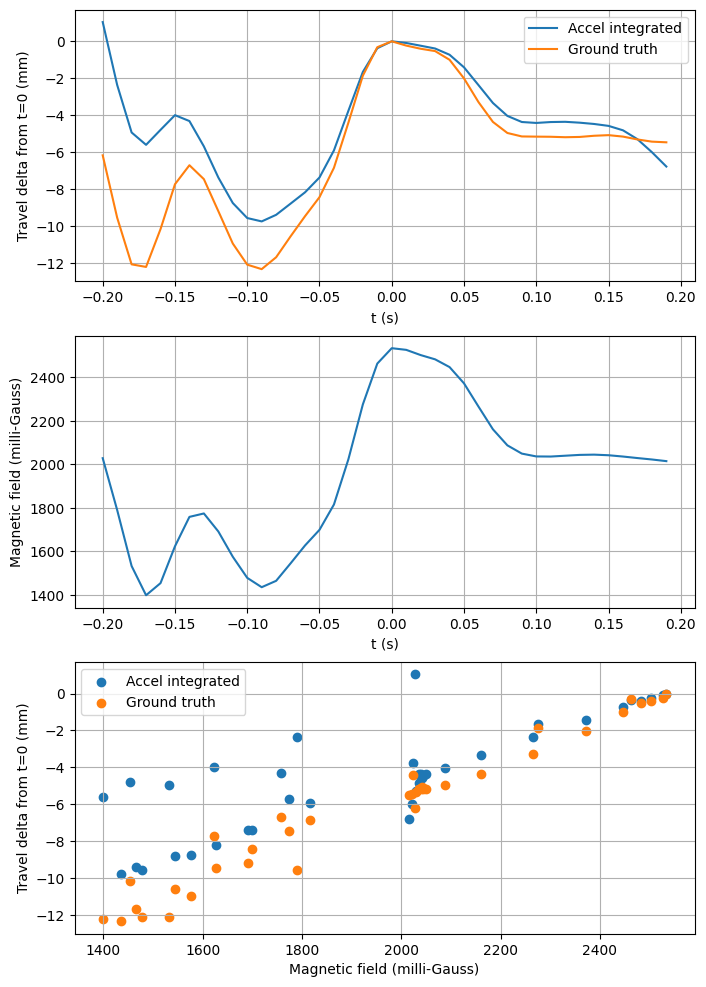

In [23]:
# Find a chunk and print some stats
# For log103, good ones are 85, 310, 196
i = 196#np.random.randint(0, len(chunks))
print("Chunk index", i)
chunk_i = chunks[i]
trav_centered = travs[i] - travs[i][zv_idx]
t_i = chunk_i.t - chunk_i.t[zv_idx]
plt.figure(figsize=(8, 12))
plt.subplot(3, 1, 1)
plt.plot(t_i, chunk_i.x, label="Accel integrated")
plt.plot(t_i, trav_centered, label="Ground truth")
plt.ylabel("Travel delta from t=0 (mm)")
plt.xlabel("t (s)")
plt.legend()
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(t_i, chunk_i.mag)
plt.xlabel("t (s)")
plt.ylabel("Magnetic field (milli-Gauss)")
plt.grid()
plt.subplot(3, 1, 3)
plt.scatter(chunk_i.mag, chunk_i.x, label="Accel integrated")
plt.scatter(chunk_i.mag, trav_centered, label="Ground truth")
plt.ylabel("Travel delta from t=0 (mm)")
plt.xlabel("Magnetic field (milli-Gauss)")
plt.legend()
plt.grid()


1723 (343, 40)
Num over s2 cap: 50 / 343
Median max s2: 59.2 mean: 64.5
Mean travel: 70.1
Mean mag: 3360.8
Mean error: 0.5

Mag to err corr: 0.044
Dtrav to err corr: 0.110
Max s2 to err corr: 0.091
Max s2 to dtrav corr: 0.588
X max to err corr: 0.122
X median to err corr: 0.101
Point X to err corr: 0.698
Point X to prop err corr: 0.664
Mean error at X 9.4: 1.461
Mean error at X 22.1: 2.653
Mean error at X 40.2: 7.405
Mean error at X 55.2: 13.203
Mean error at X 90.2: 49.165


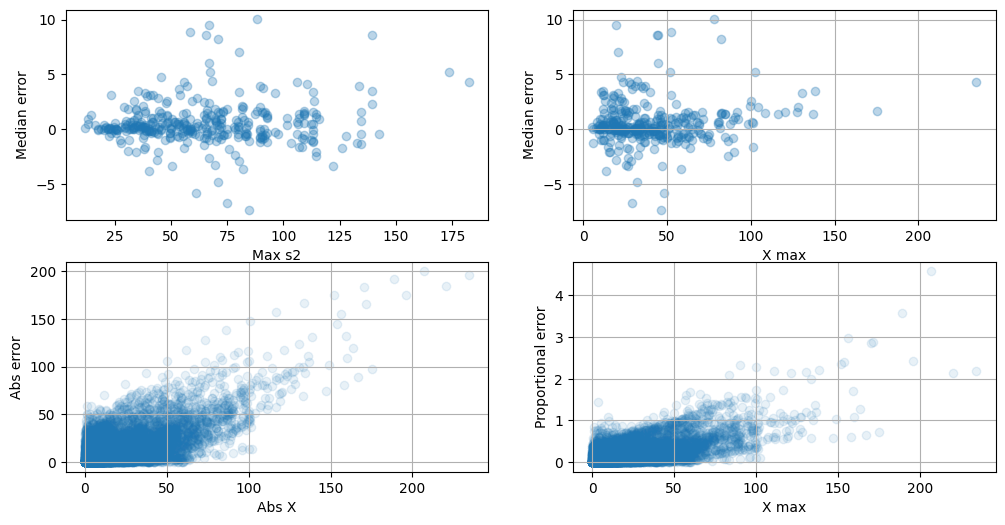

In [24]:
# Print aggregated chunk stats
print(len(mag_zv_points), err_arr.shape)
#print("Filtered", filts)

s2_over_cap = max_s2s > 100
print(f"Num over s2 cap: {np.sum(s2_over_cap)} / {len(max_s2s)}")

print(f"Median max s2: {np.median(max_s2s):.1f} mean: {np.mean(max_s2s):.1f}")
print(f"Mean travel: {np.mean(trav_meds):.1f}")
print(f"Mean mag: {np.mean(mag_meds):.1f}")
print(f"Mean error: {np.mean(err_meds):.1f}")
print()
print(f"Mag to err corr: {np.corrcoef(mag_meds, err_meds)[0, 1]:.3f}")
print(f"Dtrav to err corr: {np.corrcoef(dtravs, err_meds)[0, 1]:.3f}")
print(f"Max s2 to err corr: {np.corrcoef(max_s2s, err_meds)[0, 1]:.3f}")
print(f"Max s2 to dtrav corr: {np.corrcoef(max_s2s, dtravs)[0, 1]:.3f}")
print(f"X max to err corr: {np.corrcoef(absx_maxs, err_meds)[0, 1]:.3f}")
print(f"X median to err corr: {np.corrcoef(absx_meds, err_meds)[0, 1]:.3f}")
print(f"Point X to err corr: {np.corrcoef(abs_x_flat, abs_err_flat)[0, 1]:.3f}")


plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.scatter(max_s2s, err_meds, alpha=0.3)
plt.xlabel("Max s2")
plt.ylabel("Median error")
plt.subplot(2, 2, 2)
plt.scatter(absx_maxs, err_meds, alpha=0.3)
plt.xlabel("X max")
plt.ylabel("Median error")
plt.grid()
plt.subplot(2, 2, 3)
plt.scatter(abs_x_flat, abs_err_flat, alpha=0.1)
plt.xlabel("Abs X")
plt.ylabel("Abs error")
plt.grid()
plt.subplot(2, 2, 4)

at_flat = np.abs(trav_flat)
trav_mask_i = at_flat > 10
prop_err = abs_err_flat[trav_mask_i] / at_flat[trav_mask_i]
ax_filt = abs_x_flat[trav_mask_i]
print(f"Point X to prop err corr: {np.corrcoef(ax_filt, prop_err)[0, 1]:.3f}")

for p in np.percentile(abs_x_flat, [50, 75, 90, 95, 99]):
    mask_i = abs_x_flat > p
    mean_err_p = np.mean(err_flat[mask_i])
    print(f"Mean error at X {p:.1f}: {mean_err_p:.3f}")

plt.scatter(ax_filt, prop_err, alpha=0.1)
plt.xlabel("X max")
plt.ylabel("Proportional error")
plt.grid()

#for offset in range(-1, 2):
#    vs = np.array([np.abs(v[slice_i][chunk_len + offset]) for slice_i in slices])
#    print(f"Center offset {offset} v abs median {np.median(vs):.1f} mean {np.mean(vs):.1f}")

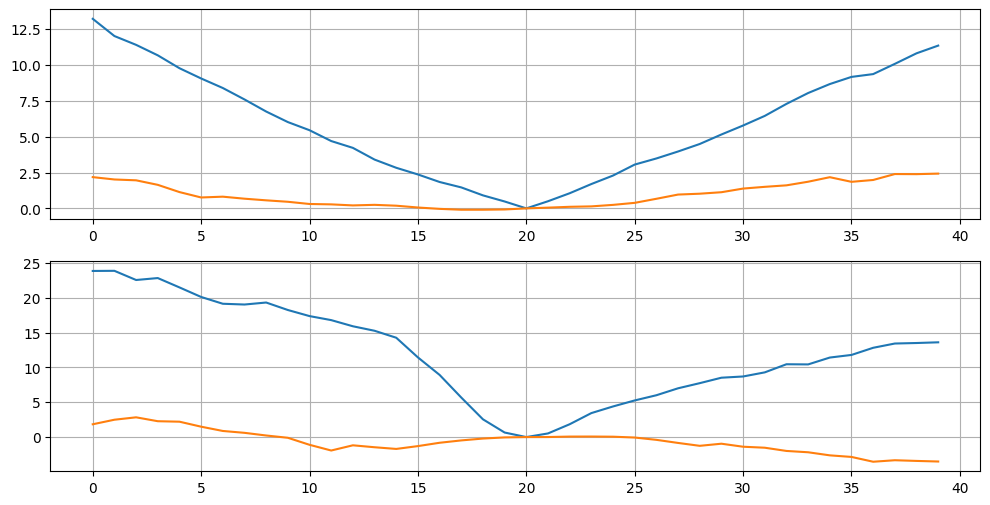

In [25]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(mae)
plt.plot(me)
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(med_abs_x)
plt.plot(med_x)
plt.grid()

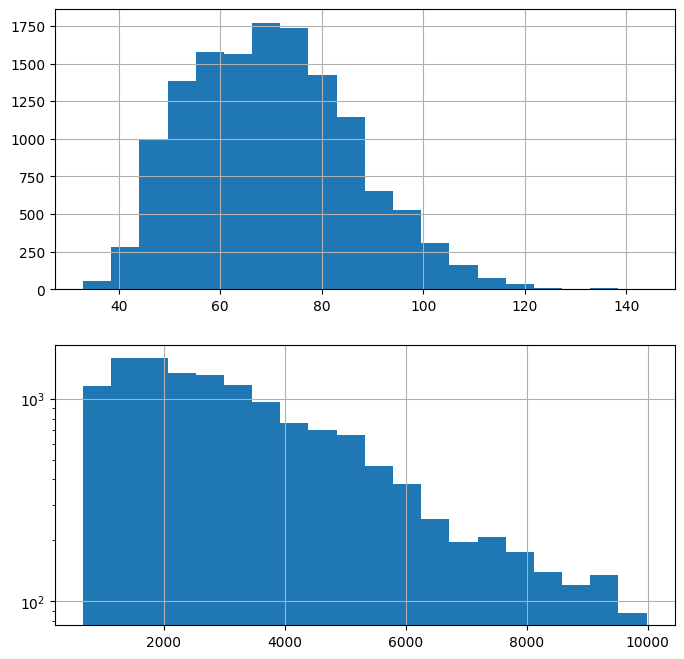

In [26]:
# Plot histogram of ground truth travel in chunks

gt_arr = np.array(travs)
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.hist(gt_arr.flatten(), bins=20)
plt.grid()

mag_arr = np.array(mags)
plt.subplot(2, 1, 2)
plt.hist(mag_arr[mag_arr < 10000].flatten(), bins=20)
plt.semilogy()
plt.grid()

/var/folders/gh/w4m5xvvx3pb1xzs57mkz_5j00000gn/T/ipykernel_74325/4223833712.py:12: RuntimeWarning: divide by zero encountered in divide
  dm_dxs = (dms / dxs)[dmdx_mask]
/var/folders/gh/w4m5xvvx3pb1xzs57mkz_5j00000gn/T/ipykernel_74325/4223833712.py:13: RuntimeWarning: invalid value encountered in divide
  dm_dts = (dms / dtravs)[dmdt_mask]
/Users/colin/Documents/projects/sus/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/colin/Documents/projects/sus/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/colin/Documents/projects/sus/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/colin/Documents/projects/sus/venv/lib/pyth

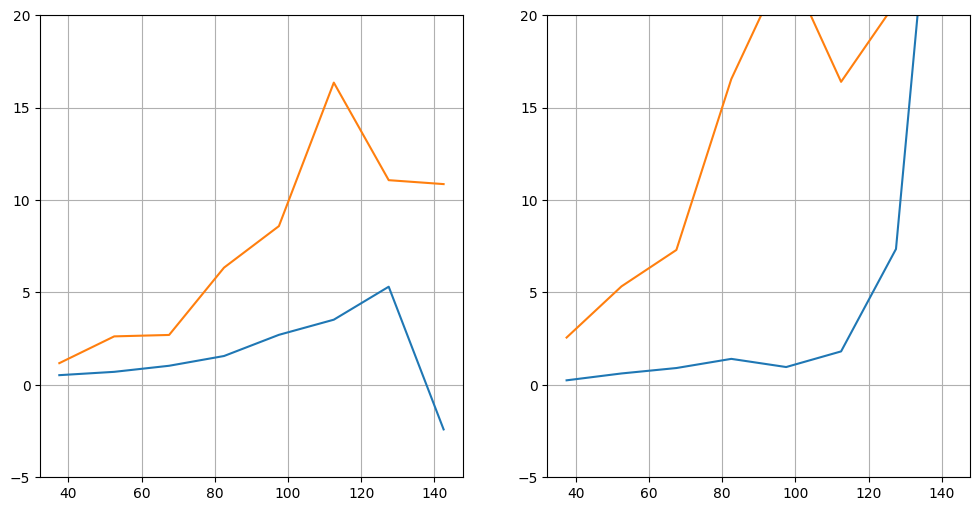

In [27]:
# Plot gradients of mag vs travel
vs = [chunk_i.v for chunk_i in chunks]
mags_arr = np.array(mags)
travs_arr = np.array(travs)
dms = np.diff(mags_arr, prepend=mags_arr[:, [0]], axis=1).flatten()
dxs = np.array(vs).flatten()
dtravs = np.diff(travs_arr, prepend=travs_arr[:, [0]], axis=1).flatten() / 0.01
mags_flat = mags_arr.flatten()
travs_flat = travs_arr.flatten()
dmdx_mask = np.abs(dxs) > 1
dmdt_mask = np.abs(dtravs) > 1
dm_dxs = (dms / dxs)[dmdx_mask]
dm_dts = (dms / dtravs)[dmdt_mask]

trav_bins = 10
bin_size = 150 / trav_bins
bin_inds = np.floor(travs_flat / bin_size).astype(int)
bin_centers = bin_size * (np.arange(trav_bins) + 0.5)
dmdx_bins = []
dmdt_bins = []
for i in range(trav_bins):
    dmdt_bins.append(dm_dts[bin_inds[dmdt_mask] == i])
    dmdx_bins.append(dm_dxs[bin_inds[dmdx_mask] == i])

plt.figure(figsize=(12, 6))
for i, data in enumerate([dmdt_bins, dmdx_bins]):
    plt.subplot(1, 2, i+1)
    stds = [np.std(bin_i) for bin_i in data]
    means = [np.mean(bin_i) for bin_i in data]
    plt.plot(bin_centers, means)
    plt.plot(bin_centers, stds)
#plt.scatter(travs_flat[dmdx_mask], dm_dxs, alpha=0.2)
#plt.scatter(travs_flat[dmdt_mask], dm_dts, alpha=0.2)
    plt.grid()
    plt.ylim(-5, 20)

In [28]:
result = model_builder.train(training_data)
print("x0, y_scale, power:", result.x)

`ftol` termination condition is satisfied.
Function evaluations 6, initial cost 2.4137e+06, final cost 2.3010e+06, first-order optimality 1.10e+00.
x0, y_scale, power: [221.733   4.75    0.327]


In [29]:
# Calc RMSE
mags_flat = mag.flatten().copy() #input_arr[:, 0, :].flatten()
x_mag_flat = model_builder.model.pred_x(mags_flat)

trav_flat = travel.flatten().copy() #np.array(gt_list).flatten()
thresh = mag_baseline
mag_thresh_mask = (mag > thresh) & boring_mask
#mag_thresh_mask = (trav_flat > 30) & boring_mask
print_err_stats(x_mag_flat[boring_mask], trav_flat[boring_mask], prefix="Mag-predicted x", center=True)
print_err_stats(x_mag_flat[mag_thresh_mask], trav_flat[mag_thresh_mask], prefix="Mag-predicted x (thresholded at 30mm)", center=True)

Mag-predicted x RMSE: 5.966, MAE: 4.253, ME: -0.000
Mag-predicted x (thresholded at 30mm) RMSE: 2.928, MAE: 2.026, ME: 0.000


(np.float64(2.9280329917415355),
 np.float64(2.0257740273464546),
 np.float64(4.072972242601559e-15))

In [ ]:
# Cut out worst chunks and retrain
res = result.fun
cut_chunks = 5#int(len(chunks) * 0.005)
print(res.shape)
chunk_residuals = np.array([res[i*(zv_idx*2-1):(i+1)*(zv_idx*2-1)] for i in range(len(chunks))])
median_chunk_residuals = np.mean(np.abs(chunk_residuals), axis=1)
print(f"Mean chunk residual std: {np.std(median_chunk_residuals):.2f}")
worst_chunks = np.argsort(median_chunk_residuals)[-cut_chunks:]
print(f"5 worst mean chunk residuals: {median_chunk_residuals[worst_chunks]}")
training_data_filt = np.array([data_i for (i, data_i) in enumerate(training_data) if i not in worst_chunks])
print("Worst chunks:", worst_chunks)
print("Residuals shape:", res.shape, chunk_residuals.shape)

result = model_builder.train(training_data_filt)
print("x0, y_scale, power:", result.x)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(trav_meds, median_chunk_residuals, alpha=0.3)
plt.subplot(1, 2, 2)
plt.scatter(err_meds, median_chunk_residuals, alpha=0.3)

(13379,)


NameError: name 'chunk_len' is not defined

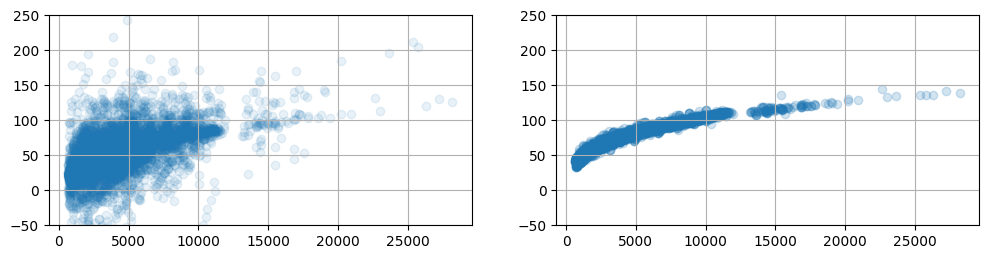

In [ ]:
# Plot x pred vs mag in chunks with their center offset by the solved prediction
zero_x_mags = training_data[:, 0, 0]
zero_x_preds = model_builder.model.pred_x(zero_x_mags)
x_acc_preds = training_data[:, 1, 1:] + zero_x_preds[:, np.newaxis]
x_acc_preds = x_acc_preds.flatten()

x_acc_gt = []
for trav_i in travs:
    x_acc_gt += trav_i[:zv_idx].tolist()
    x_acc_gt += trav_i[zv_idx+1:].tolist()
x_acc_gt = np.asarray(x_acc_gt)

mag_pts = training_data[:, 0, 1:]
mag_pts = mag_pts.flatten()

plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.scatter(mag_pts, x_acc_preds, alpha=0.1)
#plt.semilogx()
plt.ylim(-50, 250)
plt.grid()
plt.subplot(2, 2, 2)
plt.scatter(mag_pts, x_acc_gt, alpha=0.2)
#plt.semilogx()
plt.ylim(-50, 250)
plt.grid()

In [ ]:
# Calc RMSE
good_mag_mask = np.ones_like(mag_proj_bad_mask)#~mag_proj_bad_mask
mags_flat = mag[good_mag_mask].flatten().copy() #input_arr[:, 0, :].flatten()
x_mag_flat = model_builder.model.pred_x(mags_flat)

trav_flat = travel[good_mag_mask].flatten().copy() #np.array(gt_list).flatten()
#thresh = -1200#mag_baseline
#mag_thresh_mask = (mag > thresh) & boring_mask
#mag_thresh_mask = (trav_flat > 30) & boring_mask
print_err_stats(x_mag_flat[boring_mask], trav_flat[boring_mask], prefix="Mag-predicted x", center=True)
print_err_stats(x_mag_flat[mag_thresh_mask], trav_flat[mag_thresh_mask], prefix="Mag-predicted x (thresholded at 30mm)", center=True)

Mag-predicted x RMSE: 6.043, MAE: 4.265, ME: -0.000
Mag-predicted x (thresholded at 30mm) RMSE: 2.864, MAE: 1.973, ME: 0.000


(np.float64(2.8638387058972494),
 np.float64(1.9727208553073292),
 np.float64(6.720404200292573e-15))

Zero mag -705.4 pred: -28.3
26796 (72985,)
Error mask ratio 0.5755292183325341
Mag-predicted x (not centered) RMSE: 24.168, MAE: 23.400, ME: -23.400


(np.float64(24.167775952039147),
 np.float64(23.39995680534462),
 np.float64(-23.39995680534462))

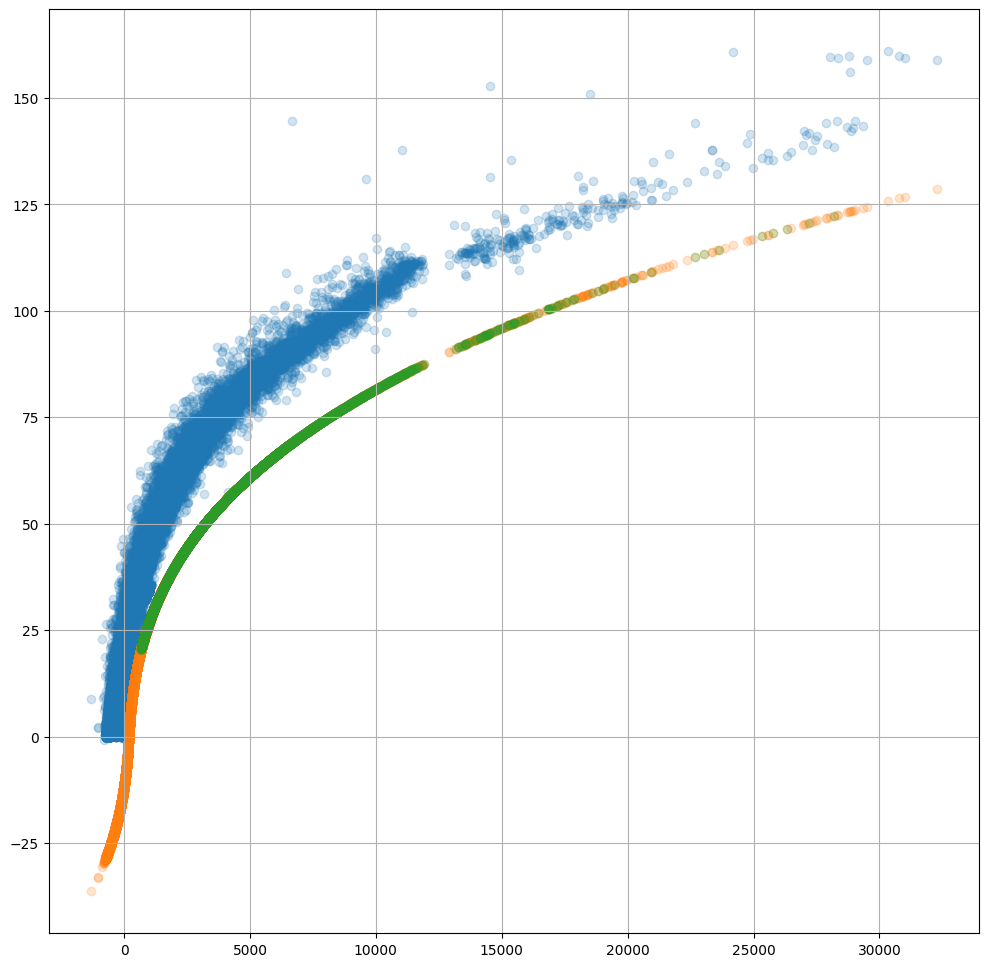

In [ ]:

trav_offset = np.mean(trav_flat)

mag_pts = training_data[:, 0, 1:]
mag_pts_preds = model_builder.model.pred_x(mag_pts)
zero_mag = np.percentile(mag, 0.5)
zero_mag_pred = model_builder.model.pred_x(zero_mag)
print(f"Zero mag {zero_mag:.1f} pred: {zero_mag_pred:.1f}")
#x_mag_flat -= zero_mag_pred

print(np.sum(mag_thresh_mask), mag_thresh_mask.shape)
print("Error mask ratio", np.sum(boring_mask) / len(boring_mask))

plt.figure(figsize=(12, 12))
plt.scatter(mags_flat, trav_flat, alpha=0.2, label="ground truth travel")
plt.scatter(mags_flat, x_mag_flat, alpha=0.2, label="predicted travel")
plt.scatter(mag_pts.flatten(), mag_pts_preds.flatten(), alpha=0.2, label="predicted travel at points")
plt.grid()

print_err_stats(x_mag_flat[boring_mask], trav_flat[boring_mask], prefix="Mag-predicted x (not centered)", center=False)

(72985,) (72985,) (72985,)
-1308.5376815956758 32269.76864711518


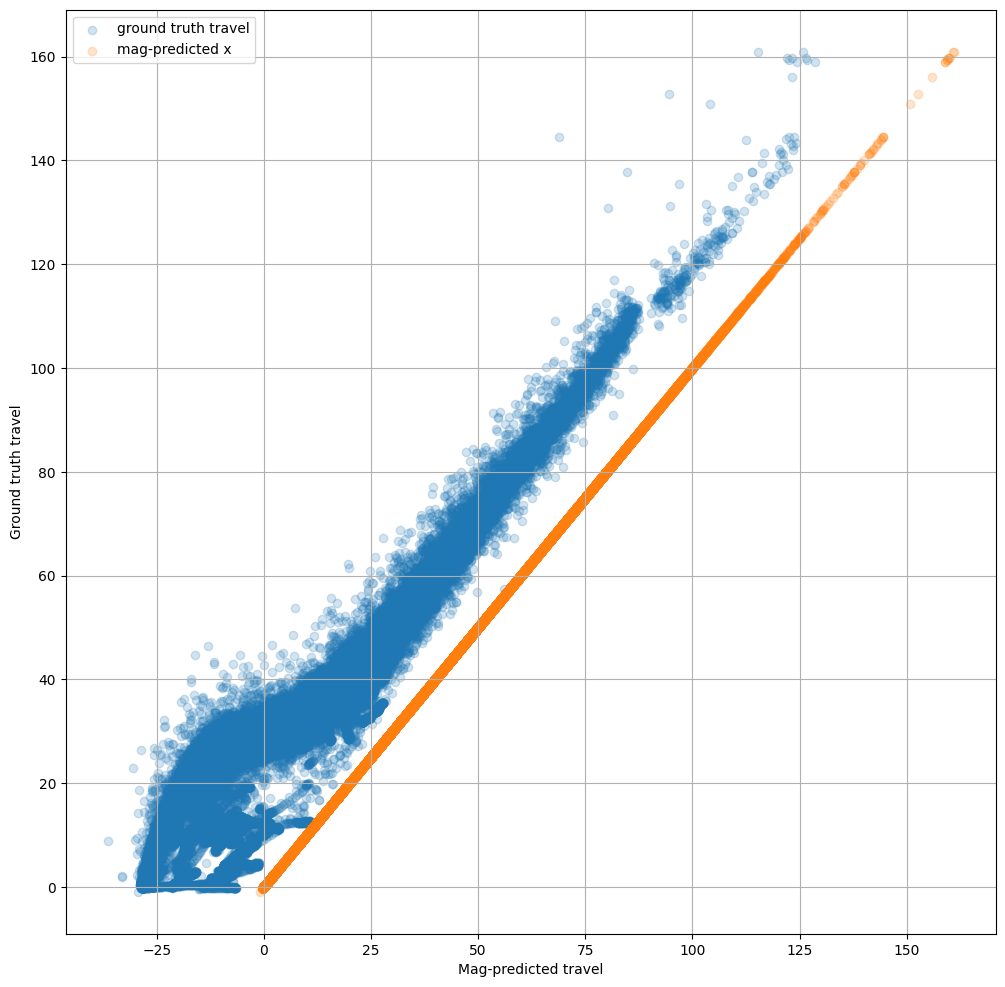

In [ ]:
# Another plot of predicted vs actual travel, colored by mag value
# zero_x_mags = input_arr[:, 0, 0]
# zero_x_preds = pred_x(zero_x_mags, result.x[0], result.x[1], result.x[2])
# print(zero_x_preds.shape)
# x_acc_pred = input_arr[:, 1, :] + zero_x_preds[:, np.newaxis] - np.mean(zero_x_preds)
# print_err_stats(x_acc_pred.flatten(), trav_flat, prefix="Accel-predicted x")

print(mags_flat.shape, x_mag_flat.shape, trav_flat.shape)
print(min(mags_flat), max(mags_flat))

plt.figure(figsize=(12, 12))
#plt.subplot(2, 1, 1)
plt.scatter(x_mag_flat, trav_flat, alpha=0.2, label="ground truth travel")
plt.scatter(trav_flat, trav_flat, alpha=0.2, label="mag-predicted x")
plt.xlabel("Mag-predicted travel")
plt.ylabel("Ground truth travel")
plt.legend()
#plt.ylim(-50, 200)
plt.grid()

# plt.subplot(2, 1, 2)
# plt.scatter(mags_flat, trav_flat, alpha=0.2, label="ground truth travel")
# plt.scatter(mags_flat, x_acc_pred.flatten(), alpha=0.5, label="accel-predicted x")
# plt.legend()
# plt.ylim(-50, 100)
# plt.grid()
# plt.show()

In [ ]:
train_mask = (mag > mag_baseline) & boring_mask
def gt_res(vec):
    x0, y_scale, power, y0 = vec[0], vec[1], vec[2], vec[3]
    return pred_x(mag[train_mask], x0, y_scale, power=power, y0=y0) - travel[train_mask]


#guess_vec = [mag_baseline, 2, 1/3, 3, 1]
guess_vec = [result.x[0], result.x[1], result.x[2], 0]
gt_result = least_squares(
                fun=gt_res,
                x0=guess_vec, 
                method="trf",
                verbose=1,
                max_nfev=1000,
                #loss='huber',
            )

mask = good_mag_mask & train_mask
mag_i = mag[mask]
trav_i = travel[mask]

gt_coeffs = gt_result.x
print(gt_coeffs)
gt_preds = pred_x(mag_i, gt_coeffs[0], gt_coeffs[1], gt_coeffs[2], gt_coeffs[3])

print_err_stats(gt_preds, trav_i, prefix="Mag-predicted x", center=False)

plt.figure(figsize=(12, 12))
plt.scatter(mag_i, trav_i, alpha=0.2, label="ground truth travel")
plt.scatter(mag_i, gt_preds, alpha=0.2, label="predicted travel")

NameError: name 'pred_x' is not defined